In [1]:
import pandas
import pm4py
import os

In [2]:
path='../Output/conv/'
csv_files = [pos_csv for pos_csv in os.listdir(path)]

log_df = pandas.DataFrame()
for index, csv in enumerate(csv_files):
    with open(os.path.join(path, csv)) as csv_file:
        case_dataframe = pandas.read_csv(csv_file)
        log_df = pandas.concat([log_df,case_dataframe])

log_df = pm4py.format_dataframe(log_df, case_id='CaseId', activity_key='Activity', timestamp_key='Timestamp')
log = pm4py.convert_to_event_log(log_df)

In [4]:
log_df['CaseId'].nunique()


290

In [5]:
log_df.shape

(3262, 9)

In [ ]:
log_df.head()

,CaseId,Timestamp,Activity,Amount,case:concept:name,concept:name,time:timestamp,@@index,@@case_index
0,item_0_0,2025-05-21 14:06:21+00:00,Place Order,1494,item_0_0,Place Order,2025-05-21 14:06:21+00:00,0,0
1,item_0_0,2025-05-23 22:38:21+00:00,Send Invoice,1494,item_0_0,Send Invoice,2025-05-23 22:38:21+00:00,1,0
2,item_0_0,2025-05-26 08:56:21+00:00,Check Availability,1494,item_0_0,Check Availability,2025-05-26 08:56:21+00:00,2,0
3,item_0_0,2025-05-27 08:45:21+00:00,Split Item,1494,item_0_0,Split Item,2025-05-27 08:45:21+00:00,3,0
4,item_0_0,2025-05-27 10:26:21+00:00,Pick Item,420,item_0_0,Pick Item,2025-05-27 10:26:21+00:00,4,0


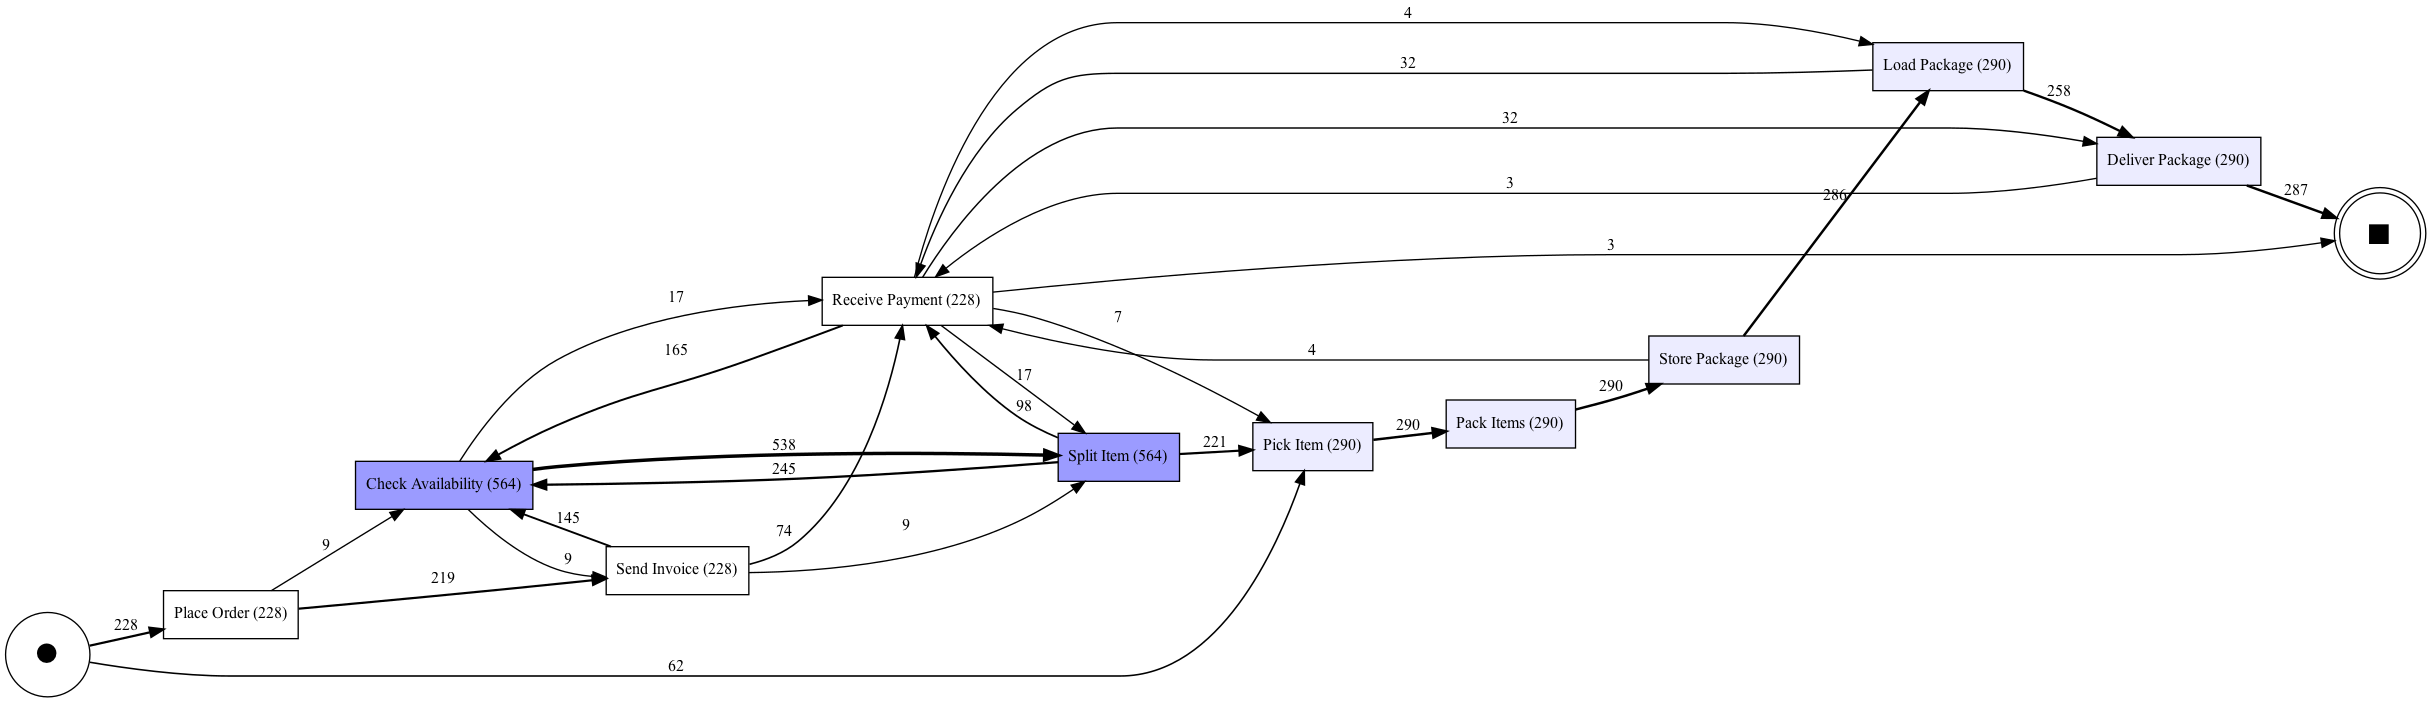

In [6]:
dfg, start, end = pm4py.discover_dfg(log)
pm4py.vis.view_dfg(dfg, start, end)

In [ ]:
log.properties

{'pm4py:param:activity_key': 'concept:name',
 'pm4py:param:timestamp_key': 'time:timestamp',
 'pm4py:param:group_key': 'org:group',
 'pm4py:param:transition_key': 'lifecycle:transition',
 'pm4py:param:resource_key': 'org:resource'}

{'attributes': {'concept:name': 'item_0_0'}, 'events': [{'CaseId': 'item_0_0', 'Timestamp': Timestamp('2025-05-21 14:06:21+0000', tz='UTC'), 'Activity': 'Place Order', 'Amount': 1494, 'concept:name': 'Place Order', 'time:timestamp': Timestamp('2025-05-21 14:06:21+0000', tz='UTC'), '@@index': 0, '@@case_index': 0}, '..', {'CaseId': 'item_0_0', 'Timestamp': Timestamp('2025-06-17 14:31:21+0000', tz='UTC'), 'Activity': 'Deliver Package', 'Amount': 340, 'concept:name': 'Deliver Package', 'time:timestamp': Timestamp('2025-06-17 14:31:21+0000', tz='UTC'), '@@index': 29, '@@case_index': 0}]}

In [ ]:
log.keys() 

AttributeError: 'EventLog' object has no attribute 'keys'